In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
from sklearn.preprocessing import MinMaxScaler
import math as ma
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

In [2]:
connect = sqlite3.connect("C:/Forge/Python/database.db")
df = pd.read_sql('SELECT * FROM weather5', connect)
connect.close()

In [3]:
def get_label_list(df, flag_print):
    label_list = df.columns.tolist() 
    for i in range(len(label_list)):
        df[label_list[i]] = pd.to_numeric(df[label_list[i]], errors='coerce') # заменяем пропуски на NaN
        if (flag_print):
            print(i, "/", i - len(label_list), ": ", label_list[i], sep="", end="  ")
    return label_list

label_list = get_label_list(df, 1)
    
mode = 1

if mode == 1:
    for i in range(len(label_list)):
        df.replace(r'^\s*$', pd.NA, regex=True, inplace=True)
    df = df.dropna()
elif mode == 2:
    # Создаём словарь средних значений
    fill_values = {col: df[col].mean() for col in label_list}

    # Заполняем пропуски во всех столбцах за один вызов
    df.fillna(fill_values, inplace=True)

df.head(-1)

0/-9: id  1/-8: year  2/-7: month  3/-6: day  4/-5: max_temp  5/-4: sr_temp  6/-3: min_temp  7/-2: precipit  8/-1: norm_plus  

,id,year,month,day,max_temp,sr_temp,min_temp,precipit,norm_plus
0,1,1881,1,1,1.0,-0.2,-1.5,1.3,6.5
1,2,1881,1,2,1.7,-1.1,-2.5,0.1,5.8
2,3,1881,1,3,1.9,1.1,-0.9,0.0,8.1
3,4,1881,1,4,2.2,1.7,0.7,0.4,8.8
4,5,1881,1,5,2.2,-6.1,-10.4,0.0,1.1
...,...,...,...,...,...,...,...,...,...
53297,53298,2026,8,15,18.8,16.1,13.5,5.0,-1.6
53298,53299,2026,8,16,22.3,18.1,14.7,1.0,0.6
53299,53300,2026,8,17,19.5,17.1,15.1,0.4,-0.3
53300,53301,2026,8,18,20.0,16.8,14.6,6.5,-0.5


In [4]:
df['year'] = df['year'].shift(-1)                               #
df['month'] = df['month'].shift(-1)                             # Перемещение календарных параметров завтра в сегодняшним параметрам погоды
df['day'] = df['day'].shift(-1)                                 #

df['sr_temp'] = df['sr_temp'].shift(-1)

step = 3
for i in range(1, step+1):
    df[f'sr_temp_to_temp_{i}'] = df['sr_temp'].shift(i) - df['sr_temp'].shift(i+1)        
# df['last_sr_temp'] = df['sr_temp'].shift(step+1)
# df['sr_temp_step_day'] = df['sr_temp'].rolling(window=step, min_periods=step).mean().shift(1)
df['sr_temp_month'] = df['sr_temp'].rolling(window=30, min_periods=30).mean().shift(1)
df['sr_temp_20days'] = df['sr_temp'].rolling(window=20, min_periods=20).mean().shift(1)
df['sr_temp_seson'] = df['sr_temp'].rolling(window=70, min_periods=70).mean().shift(1)

df['ras_temp'] = df['max_temp'] - df['min_temp']      # Получения разброса температур

df = df.dropna()

label_list = get_label_list(df, 0)

days_in_month_1 = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31] # количество дней в каждом месяце не весокостного года
days_in_month_2 = [31, 29, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31] # количество дней в каждом месяце весокостного года

def day_of_year(x):                                                                 # 
    try:                                                                            #
        if x['year'] == 400 or x['year'] % 4 == 0 and x['year'] % 100 != 0:         # 
            return sum(days_in_month_2[:int(x['month'])-1]) + int(x['day'])         # функция возвращающая номер дня в году
        else:                                                                       #
            return sum(days_in_month_1[:int(x['month'])-1]) + int(x['day'])         #
    except:                                                                         #
        pass                                                                        #

df['day_of_year'] = df[['year', 'month', 'day']].apply(day_of_year, axis=1)

scal = MinMaxScaler()
df['month'] = scal.fit_transform(df[['month']]) * 2 * ma.pi   # преобразуем номер месяца в соответствующее количество радиан, где 12-ый месяц = 6.28 радиан
df['day'] = scal.fit_transform(df[['day']]) * 2 * ma.pi        # преобразуем номер дня в месяце в соответствующее количество радиан, где последний день месяца = 6.28 радиан
df['day_of_year'] = scal.fit_transform(df[['day_of_year']]) * 2 * ma.pi    # преобразуем номер дня в году в соответствующее количество радиан, где 365 день = 6.28 радиан
def set_rad_cos(x):
    return ma.cos(x)
def set_rad_sin(x):
    return ma.sin(x)

df['month_cos'] = df['month'].apply(set_rad_cos)
df['month_sin'] = df['month'].apply(set_rad_sin)

df['day_cos'] = df['day'].apply(set_rad_cos)
df['day_sin'] = df['day'].apply(set_rad_sin)

df['day_of_year_cos'] = df['day_of_year'].apply(set_rad_cos)
df['day_of_year_sin'] = df['day_of_year'].apply(set_rad_sin)

df = df.drop(['id', 'day_of_year', 'month', 'day', 'max_temp', 'min_temp', 'norm_plus'], axis=1)         # убираем все ненужные колонки датасета

label_list = get_label_list(df, 1)
print()
df.head(-1)

0/-16: year  1/-15: sr_temp  2/-14: precipit  3/-13: sr_temp_to_temp_1  4/-12: sr_temp_to_temp_2  5/-11: sr_temp_to_temp_3  6/-10: sr_temp_month  7/-9: sr_temp_20days  8/-8: sr_temp_seson  9/-7: ras_temp  10/-6: month_cos  11/-5: month_sin  12/-4: day_cos  13/-3: day_sin  14/-2: day_of_year_cos  15/-1: day_of_year_sin  


,year,sr_temp,precipit,sr_temp_to_temp_1,sr_temp_to_temp_2,sr_temp_to_temp_3,sr_temp_month,sr_temp_20days,sr_temp_seson,ras_temp,month_cos,month_sin,day_cos,day_sin,day_of_year_cos,day_of_year_sin
71,1881.0,-6.3,0.4,-0.3,-0.6,-3.2,-8.240000,-9.690,-10.184286,6.9,0.415415,0.909632,-0.809017,5.877853e-01,0.341571,0.939856
72,1881.0,-9.0,0.0,-1.5,-0.3,-0.6,-8.473333,-9.335,-10.258571,4.9,0.415415,0.909632,-0.913545,4.067366e-01,0.325342,0.945596
73,1881.0,-13.6,0.0,-2.7,-1.5,-0.3,-8.796667,-9.155,-10.402857,11.6,0.415415,0.909632,-0.978148,2.079117e-01,0.309017,0.951057
74,1881.0,-7.0,0.0,-4.6,-2.7,-1.5,-8.910000,-9.055,-10.621429,17.3,0.415415,0.909632,-1.000000,1.224647e-16,0.292600,0.956235
75,1881.0,-4.4,0.0,6.6,-4.6,-2.7,-8.790000,-8.735,-10.634286,13.6,0.415415,0.909632,-0.978148,-2.079117e-01,0.276097,0.961130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53296,2026.0,16.1,0.0,0.3,-0.5,-2.4,18.803333,19.235,18.588571,10.7,-0.654861,-0.755750,-0.978148,2.079117e-01,-0.732494,-0.680773
53297,2026.0,18.1,5.0,0.8,0.3,-0.5,18.713333,18.990,18.485714,5.3,-0.654861,-0.755750,-1.000000,1.224647e-16,-0.720667,-0.693281
53298,2026.0,17.1,1.0,2.0,0.8,0.3,18.676667,18.710,18.487143,7.6,-0.654861,-0.755750,-0.978148,-2.079117e-01,-0.708627,-0.705584
53299,2026.0,16.8,0.4,-1.0,2.0,0.8,18.473333,18.585,18.454286,4.4,-0.654861,-0.755750,-0.913545,-4.067366e-01,-0.696376,-0.717677


In [5]:
x = pd.DataFrame(df.copy().iloc[:, [i for i in range(len(label_list)) if (i not in [1])]])
y = pd.DataFrame(df.copy().iloc[:, [1]])

# mode = 1
# if mode == 1:
#     train_size = int(len(x) * 0.8)
#     x_train, x_test = x[:train_size], x[train_size:]
#     y_train, y_test = y[:train_size], y[train_size:]
# elif mode == 2:
#     x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state = 0)

# print("То от чего предсказывем:", x_test.columns.to_list())
# print("То что предсказывем:", y_test.columns.tolist())

53121
Набор данных делится на 3
Выбран отрезок от 0 до 17707


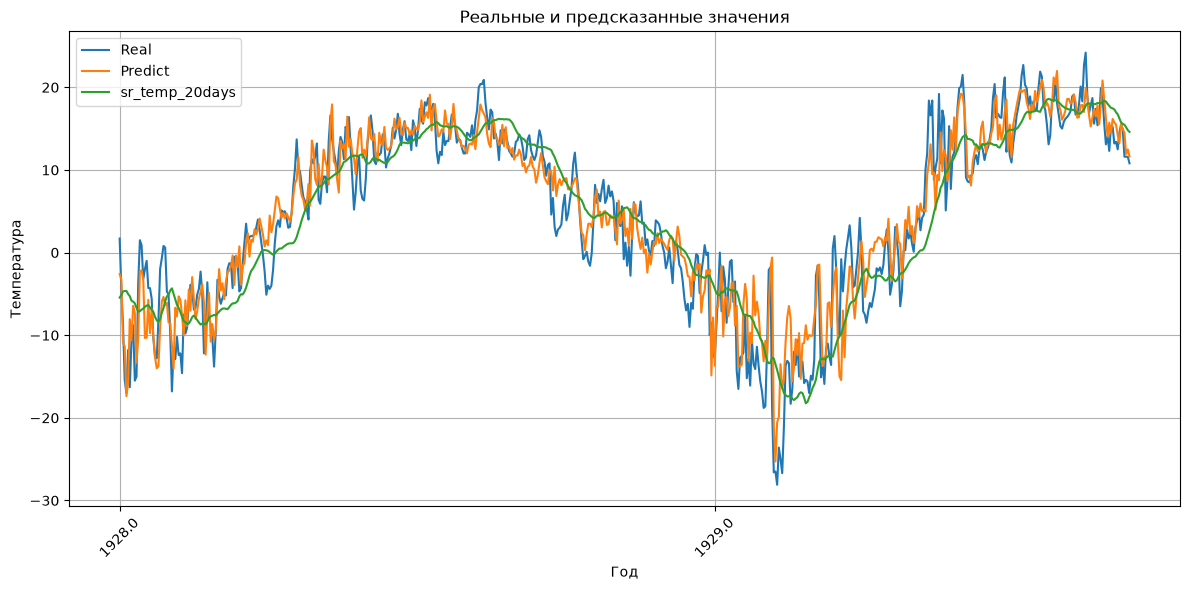

coef:
       year  precipit  sr_temp_to_temp_1  sr_temp_to_temp_2  \
0  0.003533  0.004758           0.026733           0.012828   

   sr_temp_to_temp_3  sr_temp_month  sr_temp_20days  sr_temp_seson  ras_temp  \
0           0.012474       0.004268        0.813125       0.004526    0.0194   

   month_cos  month_sin   day_cos  day_sin  day_of_year_cos  day_of_year_sin  
0   0.008257   0.002614  0.002582  0.00251         0.075877         0.006516  
------------------------
# MAE и MSE по обучающей выборке
Train MSE:  7.6576762199401855
Train MAE:  2.1391921043395996
------------------------
# MAE и MSE по тестовой выборке
Test MSE:  12.88420581817627
Test MAE:  2.7367825508117676
------------------------
R^2: 0.8771713376045227


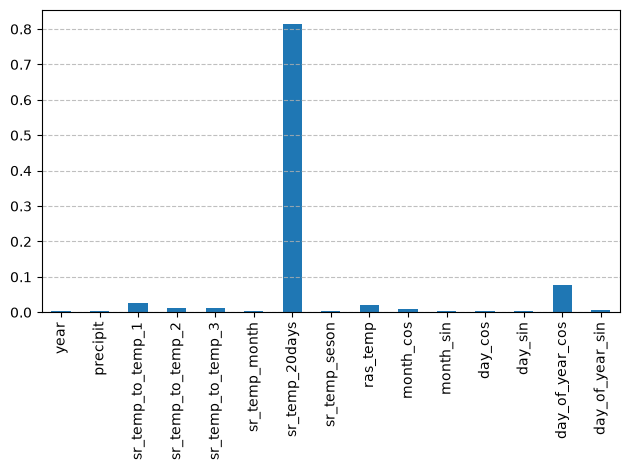

Выбран отрезок от 17707 до 35414


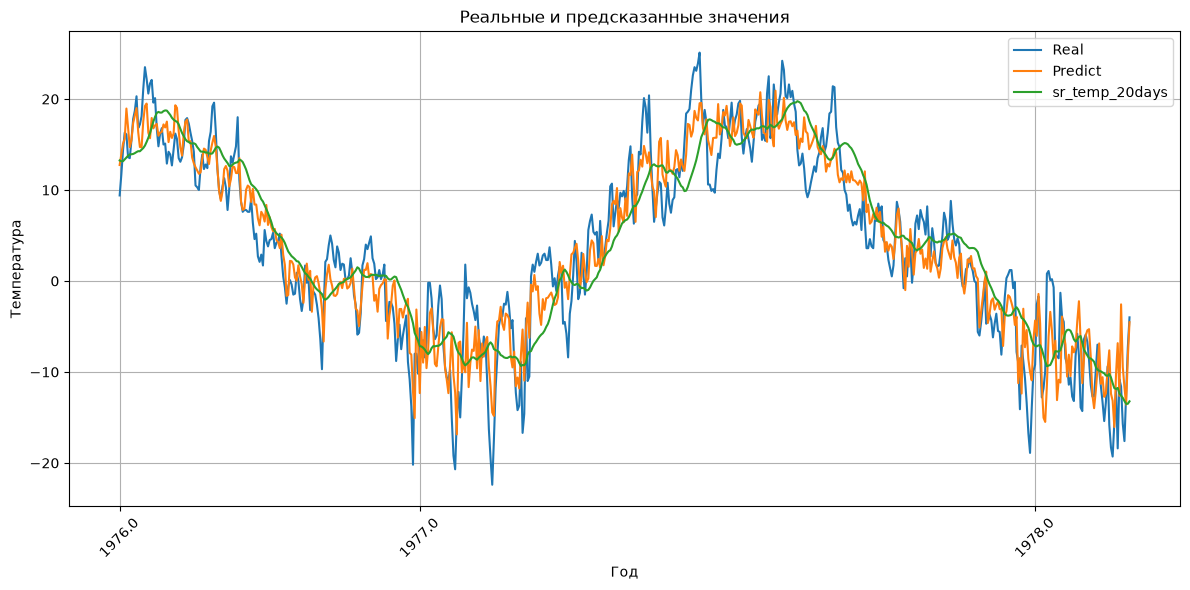

coef:
       year  precipit  sr_temp_to_temp_1  sr_temp_to_temp_2  \
0  0.003824  0.007347           0.027897           0.013078   

   sr_temp_to_temp_3  sr_temp_month  sr_temp_20days  sr_temp_seson  ras_temp  \
0           0.012794       0.004111        0.782302       0.004915  0.020684   

   month_cos  month_sin   day_cos   day_sin  day_of_year_cos  day_of_year_sin  
0   0.020397   0.002978  0.002433  0.003759         0.086668         0.006813  
------------------------
# MAE и MSE по обучающей выборке
Train MSE:  8.11935043334961
Train MAE:  2.1937780380249023
------------------------
# MAE и MSE по тестовой выборке
Test MSE:  11.42413330078125
Test MAE:  2.5854904651641846
------------------------
R^2: 0.8906742334365845


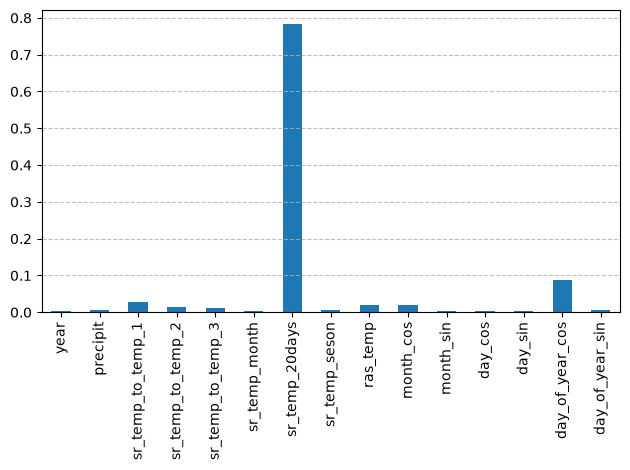

Выбран отрезок от 35414 до 53121


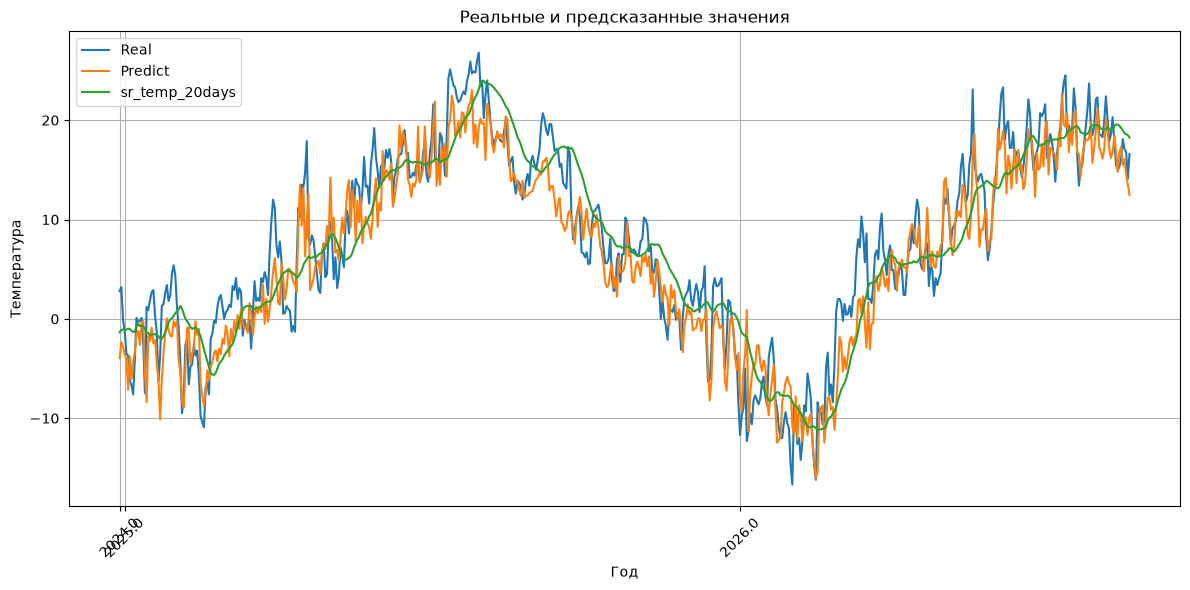

coef:
       year  precipit  sr_temp_to_temp_1  sr_temp_to_temp_2  \
0  0.003316  0.006056            0.02725           0.013662   

   sr_temp_to_temp_3  sr_temp_month  sr_temp_20days  sr_temp_seson  ras_temp  \
0           0.010879       0.005102        0.795208       0.005229  0.016428   

   month_cos  month_sin   day_cos   day_sin  day_of_year_cos  day_of_year_sin  
0   0.023855   0.003596  0.003567  0.002955         0.068704         0.014194  
------------------------
# MAE и MSE по обучающей выборке
Train MSE:  8.358105659484863
Train MAE:  2.2356011867523193
------------------------
# MAE и MSE по тестовой выборке
Test MSE:  12.390504837036133
Test MAE:  2.7420387268066406
------------------------
R^2: 0.8691595792770386


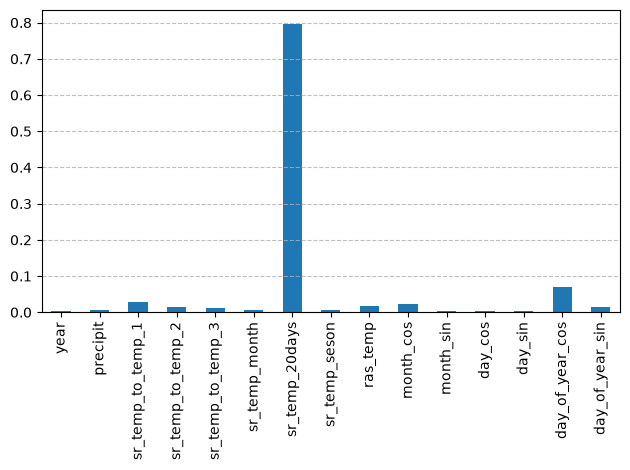

,Predicted
71,-6.585657
72,-7.587171
73,-7.614821
74,-9.784477
75,-4.360557
...,...
53296,17.330774
53297,15.467671
53298,16.067228
53299,14.583104


In [6]:
from xgboost import XGBRegressor
import numpy as np
print(len(df))
drop_numer = 2
for i in range(3, 20):
    if len(df) % i == 0:
        drop_numer = i
        break

df_predict = pd.DataFrame({'Predicted': np.nan}, index=df.index)
naget = len(df) // drop_numer
print('Набор данных делится на', drop_numer)
for i in range(drop_numer):
    df_naget = df.iloc[i*(naget): (i+1)*(naget)]
    df_unnaget = df.drop(df_naget.index)
    print(f'Выбран отрезок от {i*(naget)} до {(i+1)*(naget)}')

    label_list = get_label_list(df_naget, 0)

    label_number_list = [i for i in range(len(label_list)) if (i not in [1])]

    x_train, x_test = df_unnaget.iloc[:, label_number_list], df_naget.iloc[:,label_number_list]
    y_train, y_test = df_unnaget.iloc[:, [1]], df_naget.iloc[:, [1]]

    model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5)
    model.fit(x_train, y_train)

    y_pred_train = model.predict(x_train)
    y_pred_test = model.predict(x_test)

    df_predict.loc[df_naget.index, 'Predicted'] = y_pred_test

    deep = 600

    label_list = pd.DataFrame(x_test).columns.tolist()

    m = model.feature_importances_
    maxm = 0
    name_max = 0
    cof = pd.DataFrame()
    for i in range(len(label_list)):
        cof[label_list[i]] = [m[i]]
        if m[i] > maxm:
            maxm = m[i]
            name_max = label_list[i]


    real_vals = y_test['sr_temp'].values[-deep:]
    pred_vals = y_pred_test[-deep:]

    x_indexes = range(len(real_vals))

    plt.figure(figsize=(12, 6))
    plt.plot(x_indexes, real_vals, label='Real')
    plt.plot(x_indexes, pred_vals, label='Predict')
    plt.plot(x_indexes, df_naget[name_max][-deep:], label=name_max)
    df_tail = df_naget.iloc[-deep:]

    years = df_tail['year'].values
    change_points = [0]
    for i in range(1, len(years)):
        if years[i] != years[i-1]:
            change_points.append(i)

    tick_positions = change_points
    tick_labels = [str(years[pos]) for pos in change_points]

    plt.xticks(tick_positions, tick_labels, rotation=45)

    plt.xlabel('Год')
    plt.ylabel('Температура')
    plt.title('Реальные и предсказанные значения')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


    print('coef:')
    print(cof)
    df_tail = df_naget.dropna()

    print("------------------------")
    print("# MAE и MSE по обучающей выборке")
    print("Train MSE: ", mean_squared_error(y_train, y_pred_train))
    print("Train MAE: ", mean_absolute_error(y_train, y_pred_train))

    print("------------------------")
    print("# MAE и MSE по тестовой выборке")
    print("Test MSE: ", mean_squared_error(y_test, y_pred_test))
    print("Test MAE: ", mean_absolute_error(y_test, y_pred_test))

    print("------------------------")
    r = r2_score(y_test, y_pred_test)
    p = len(label_list)
    print("R^2:", r)

    coef_col_par = pd.DataFrame({
        "Параметр": [label_list],
        "коэффициент": [model.feature_importances_]})

    cof.iloc[0].plot(kind='bar')
    plt.grid(axis='y', linestyle='--', alpha=0.8)
    plt.tight_layout()
    plt.show()

df_predict.head(-1)

In [7]:
df['Predicted'] = df_predict['Predicted'] - df['sr_temp'].shift(1)

label_list = get_label_list(df, 1)

x = pd.DataFrame(df.copy().iloc[:, [i for i in range(len(label_list)) if (i not in [1])]])
y = pd.DataFrame(df.copy().iloc[:, [1]])

train_size = int(len(x) * 0.8)
x_train, x_test = x[:train_size], x[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(max_depth=10, max_features=5)
model.fit(x_train,y_train)

y_pred_train = model.predict(x_train)
y_pred_test = model.predict(x_test)

df['Real'] = df['sr_temp']
y_pred_df = pd.DataFrame({'Predicted2': y_pred_test}, index=y_test.index)
df = df.join(y_pred_df, how='left')
df.head(-1)


0/-17: year  1/-16: sr_temp  2/-15: precipit  3/-14: sr_temp_to_temp_1  4/-13: sr_temp_to_temp_2  5/-12: sr_temp_to_temp_3  6/-11: sr_temp_month  7/-10: sr_temp_20days  8/-9: sr_temp_seson  9/-8: ras_temp  10/-7: month_cos  11/-6: month_sin  12/-5: day_cos  13/-4: day_sin  14/-3: day_of_year_cos  15/-2: day_of_year_sin  16/-1: Predicted  

c:\Users\ivanh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,year,sr_temp,precipit,sr_temp_to_temp_1,sr_temp_to_temp_2,sr_temp_to_temp_3,sr_temp_month,sr_temp_20days,sr_temp_seson,ras_temp,month_cos,month_sin,day_cos,day_sin,day_of_year_cos,day_of_year_sin,Predicted,Real,Predicted2
71,1881.0,-6.3,0.4,-0.3,-0.6,-3.2,-8.240000,-9.690,-10.184286,6.9,0.415415,0.909632,-0.809017,5.877853e-01,0.341571,0.939856,NaN,-6.3,NaN
72,1881.0,-9.0,0.0,-1.5,-0.3,-0.6,-8.473333,-9.335,-10.258571,4.9,0.415415,0.909632,-0.913545,4.067366e-01,0.325342,0.945596,-1.287171,-9.0,NaN
73,1881.0,-13.6,0.0,-2.7,-1.5,-0.3,-8.796667,-9.155,-10.402857,11.6,0.415415,0.909632,-0.978148,2.079117e-01,0.309017,0.951057,1.385179,-13.6,NaN
74,1881.0,-7.0,0.0,-4.6,-2.7,-1.5,-8.910000,-9.055,-10.621429,17.3,0.415415,0.909632,-1.000000,1.224647e-16,0.292600,0.956235,3.815523,-7.0,NaN
75,1881.0,-4.4,0.0,6.6,-4.6,-2.7,-8.790000,-8.735,-10.634286,13.6,0.415415,0.909632,-0.978148,-2.079117e-01,0.276097,0.961130,2.639443,-4.4,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53296,2026.0,16.1,0.0,0.3,-0.5,-2.4,18.803333,19.235,18.588571,10.7,-0.654861,-0.755750,-0.978148,2.079117e-01,-0.732494,-0.680773,2.030774,16.1,17.806656
53297,2026.0,18.1,5.0,0.8,0.3,-0.5,18.713333,18.990,18.485714,5.3,-0.654861,-0.755750,-1.000000,1.224647e-16,-0.720667,-0.693281,-0.632329,18.1,16.426592
53298,2026.0,17.1,1.0,2.0,0.8,0.3,18.676667,18.710,18.487143,7.6,-0.654861,-0.755750,-0.978148,-2.079117e-01,-0.708627,-0.705584,-2.032772,17.1,17.702974
53299,2026.0,16.8,0.4,-1.0,2.0,0.8,18.473333,18.585,18.454286,4.4,-0.654861,-0.755750,-0.913545,-4.067366e-01,-0.696376,-0.717677,-2.516896,16.8,17.009192


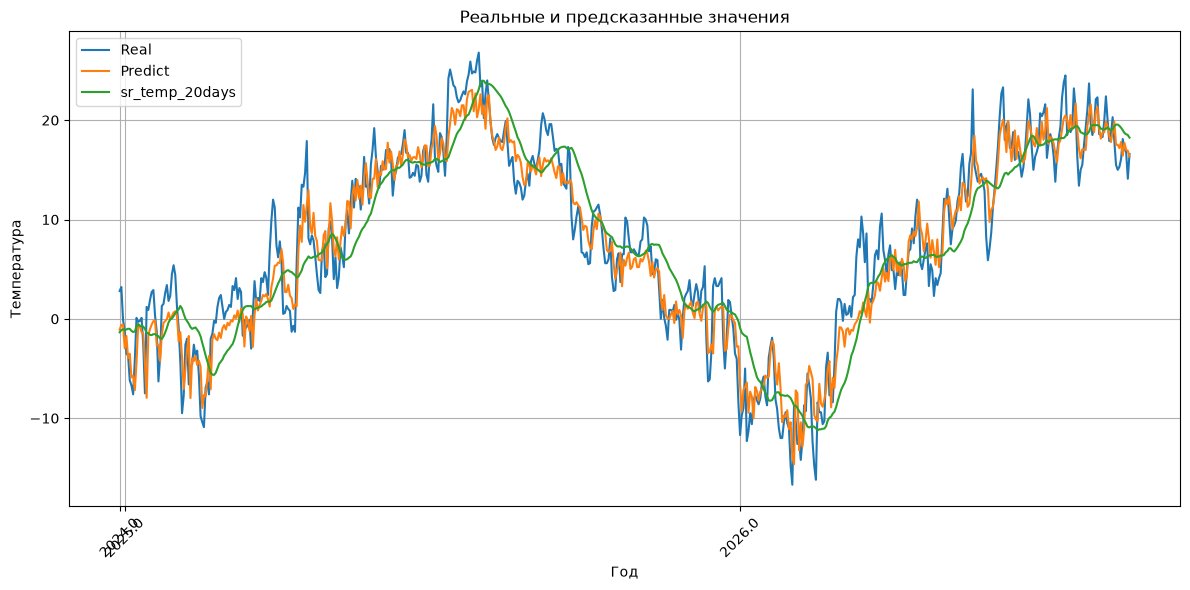

coef:
      year  precipit  sr_temp_to_temp_1  sr_temp_to_temp_2  sr_temp_to_temp_3  \
0  0.00126  0.002626           0.021816            0.00469           0.002871   

   sr_temp_month  sr_temp_20days  sr_temp_seson  ras_temp  month_cos  \
0       0.199949        0.331273       0.073597  0.016245   0.113911   

   month_sin   day_cos  day_sin  day_of_year_cos  day_of_year_sin  Predicted  
0   0.034466  0.000618   0.0007         0.119823          0.02433   0.051825  
------------------------
# MAE и MSE по обучающей выборке
Train MSE:  6.704405865301076
Train MAE:  1.9723712508009064
------------------------
# MAE и MSE по тестовой выборке
Test MSE:  7.540673858536798
Test MAE:  2.1080377478922085
------------------------
R^2: 0.9201176667725215


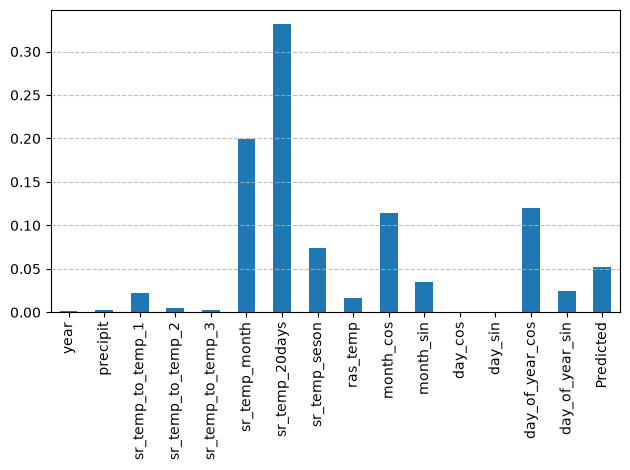

In [8]:
deep = 600

label_list = pd.DataFrame(x_test).columns.tolist()

m = model.feature_importances_
maxm = 0
name_max = 0
cof = pd.DataFrame()
for i in range(len(label_list)):
    cof[label_list[i]] = [m[i]]
    if m[i] > maxm:
        maxm = m[i]
        name_max = label_list[i]


real_vals = y_test['sr_temp'].values[-deep:]
pred_vals = y_pred_test[-deep:]

x_indexes = range(len(real_vals))

plt.figure(figsize=(12, 6))
plt.plot(x_indexes, real_vals, label='Real')
plt.plot(x_indexes, pred_vals, label='Predict')
plt.plot(x_indexes, df_naget[name_max][-deep:], label=name_max)
df_tail = df_naget.iloc[-deep:]

years = df_tail['year'].values
change_points = [0]
for i in range(1, len(years)):
    if years[i] != years[i-1]:
        change_points.append(i)

tick_positions = change_points
tick_labels = [str(years[pos]) for pos in change_points]

plt.xticks(tick_positions, tick_labels, rotation=45)

plt.xlabel('Год')
plt.ylabel('Температура')
plt.title('Реальные и предсказанные значения')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


print('coef:')
print(cof)
df_tail = df_naget.dropna()

print("------------------------")
print("# MAE и MSE по обучающей выборке")
print("Train MSE: ", mean_squared_error(y_train, y_pred_train))
print("Train MAE: ", mean_absolute_error(y_train, y_pred_train))

print("------------------------")
print("# MAE и MSE по тестовой выборке")
print("Test MSE: ", mean_squared_error(y_test, y_pred_test))
print("Test MAE: ", mean_absolute_error(y_test, y_pred_test))

print("------------------------")
r = r2_score(y_test, y_pred_test)
p = len(label_list)
print("R^2:", r)

coef_col_par = pd.DataFrame({
    "Параметр": [label_list],
    "коэффициент": [model.feature_importances_]})

cof.iloc[0].plot(kind='bar')
plt.grid(axis='y', linestyle='--', alpha=0.8)
plt.tight_layout()
plt.show()